In [1]:
# set paths
log_dir = "logfiles"
pickle_3g_0e = "logfiles/log_pickle_3g_0epochs.txt"

In [1]:
# import modules
import matplotlib.pyplot as plt
import pandas as pd
import os

In [76]:
# read log files
lpf = {}

for file in os.listdir(log_dir):
    filepath = os.path.join(log_dir, file)
    name = file.replace("log_pickle_", "").replace(".txt", "")

    with open(filepath, "r", encoding = "utf-8") as f:
        lines = f.readlines()

        lpf[name] = lines


In [ ]:
# get evaluation on test data

def read_metrics(lines_per_file: dict):

    eval_on_test = {}

    for row_name, lines in lines_per_file.items():

        for i in range(len(lines)):
            if "Evaluate on test" in lines[i]:
                metrics = {
                    "mr" : float(lines[i+1].split("   ")[1].split(" ")[1].strip()),
                    "mrr" : float(lines[i+2].split("   ")[1].split(" ")[1].strip()),
                    "hits@1" : float(lines[i+3].split("   ")[1].split(" ")[1].strip()),
                    "hits@3" : float(lines[i+4].split("   ")[1].split(" ")[1].strip()),
                    "hits@10" : float(lines[i+5].split("   ")[1].split(" ")[1].strip()),
                }
                eval_on_test[row_name] = metrics

    return pd.DataFrame(eval_on_test).T

df = read_metrics(lpf)
df

,mr,mrr,hits@1,hits@3,hits@10
3g_00epochs,762.595,0.099275,0.058139,0.134884,0.165116
3g_01epochs,556.163,0.142495,0.106977,0.162791,0.204651
3g_05epochs,531.749,0.145636,0.111628,0.158140,0.197674
4g_00epochs,621.698,0.111338,0.062791,0.151163,0.172093
4g_01epochs,538.656,0.143990,0.109302,0.160465,0.197674
4g_05epochs,525.242,0.142757,0.109302,0.155814,0.202326
4g_10epochs,515.302,0.144574,0.106977,0.165116,0.193023
4g_20epochs,549.188,0.152926,0.123256,0.167442,0.202326
50g_00epochs,640.909,0.088363,0.055814,0.109302,0.141860
50g_01epochs,551.386,0.151141,0.118605,0.160465,0.202326


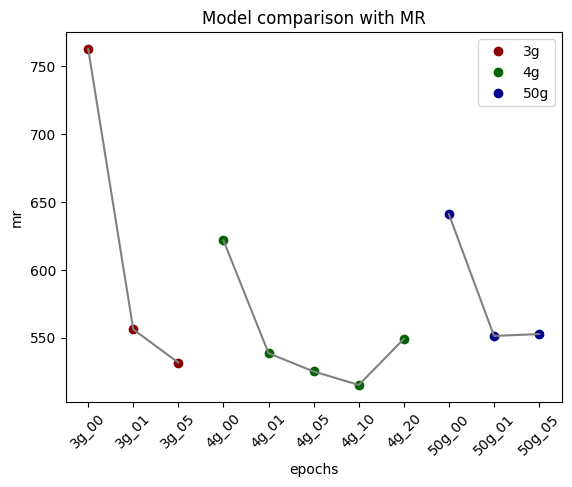

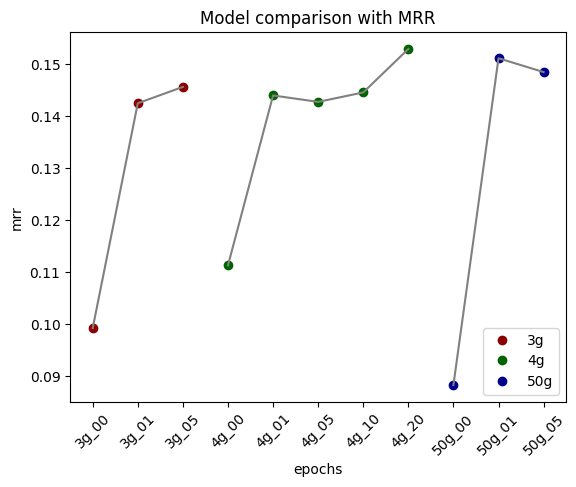

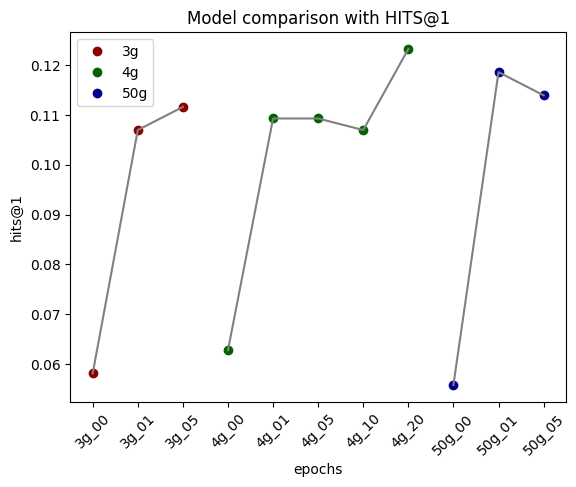

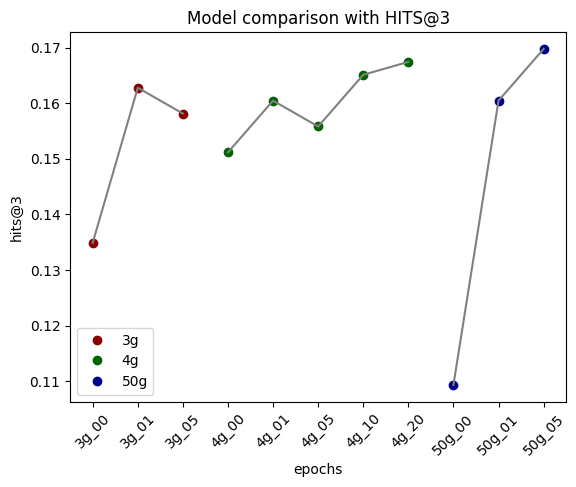

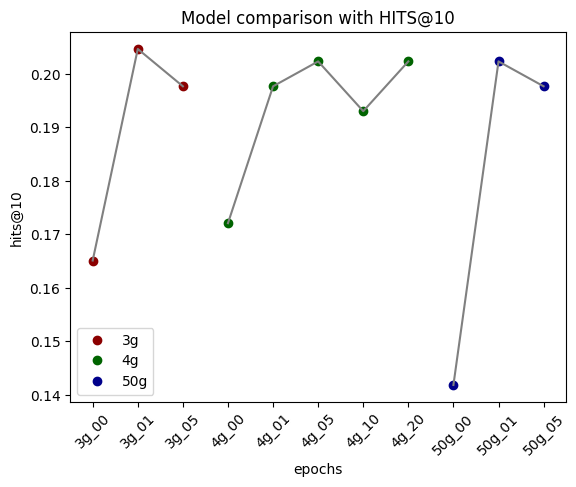

In [79]:
def plot_per_metric(df, col_name):

    # get respective column from dataframe
    vals = df[col_name]
    
    # plot datapoints
    fig, ax = plt.subplots()
    xlabels = []
    for idx, val in zip(vals.index, vals):
        if (name := "3g") in idx:
            colour = "darkred"
        elif (name := "4g") in idx:
            colour = "darkgreen"
        elif (name := "50g") in idx:
            colour = "darkblue"

        xlabel = idx.replace("epochs", "")
        xlabels.append(xlabel)

        if "00" in xlabel:
            ax.plot(xlabel, val, "o", color = colour, label = name)
        else:
            ax.plot(xlabel, val, "o", color = colour)

    # plot curves over datapoints
    ax.plot(xlabels[0:3], vals[0:3], color = "grey")
    ax.plot(xlabels[3:8], vals[3:8], color = "grey")
    ax.plot(xlabels[8:], vals[8:], color = "grey")

    # configure plot
    ax.set_title(f"Model comparison with {col_name.upper()}")
    ax.tick_params(axis='x', labelrotation=45,)
    ax.set_ylabel(col_name)
    ax.set_xlabel("epochs")
    ax.legend()


plot_per_metric(df, "mr")
plot_per_metric(df, "mrr")
plot_per_metric(df, "hits@1")
plot_per_metric(df, "hits@3")
plot_per_metric(df, "hits@10")


In [100]:
# get average binary cross entropy loss during finetuning

def get_finetuning_loss(lines_per_file: dict):

    finetuning_loss = {}

    for row_name, lines in lines_per_file.items():
        epoch = -1
        loss_per_model = {}

        for l in lines:
            if "Epoch" and "end" in l:
                epoch = int(l.split("   ")[1].split(" ")[1])
            if "average binary cross entropy" in l:
                loss = float(l.split("   ")[1].split(": ")[1].strip())
                loss_per_model[epoch] = loss

        finetuning_loss[row_name] = loss_per_model

    return finetuning_loss

ftl = get_finetuning_loss(lpf)
ftl

{'3g_00epochs': {},
 '3g_01epochs': {0: 0.634156},
 '3g_05epochs': {0: 0.634312,
  1: 0.619923,
  2: 0.616265,
  3: 0.618493,
  4: 0.615269},
 '4g_00epochs': {},
 '4g_01epochs': {0: 0.627933},
 '4g_05epochs': {0: 0.627962,
  1: 0.620644,
  2: 0.616042,
  3: 0.618562,
  4: 0.61411},
 '4g_10epochs': {0: 0.62806,
  1: 0.61989,
  2: 0.616524,
  3: 0.618057,
  4: 0.614723,
  5: 0.617128,
  6: 0.61599,
  7: 0.6167,
  8: 0.613314,
  9: 0.618126},
 '4g_20epochs': {0: 0.627758,
  1: 0.619714,
  2: 0.616114,
  3: 0.619494,
  4: 0.614469,
  5: 0.617669,
  6: 0.6158,
  7: 0.616845,
  8: 0.613146,
  9: 0.617439,
  10: 0.614545,
  11: 0.616316,
  12: 0.615342,
  13: 0.612862,
  14: 0.612569,
  15: 0.613813,
  16: 0.613558,
  17: 0.613945,
  18: 0.612254,
  19: 0.611417},
 '50g_00epochs': {},
 '50g_01epochs': {0: 0.627678},
 '50g_05epochs': {0: 0.628556,
  1: 0.619679,
  2: 0.616138,
  3: 0.618252,
  4: 0.613896}}

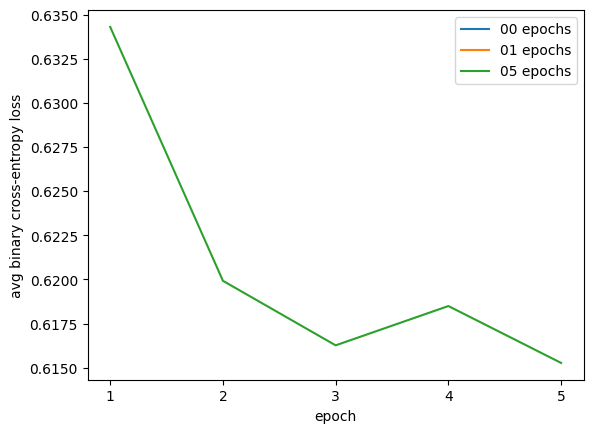

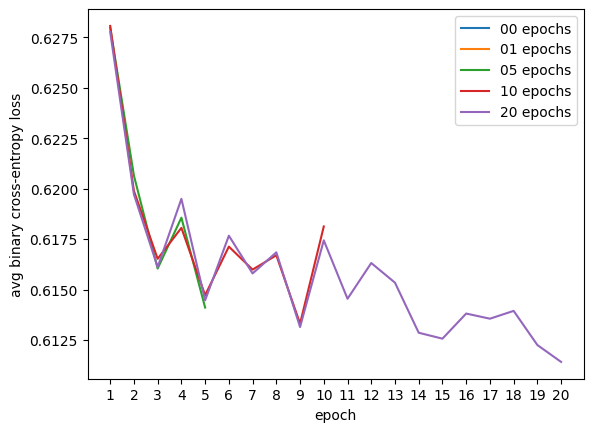

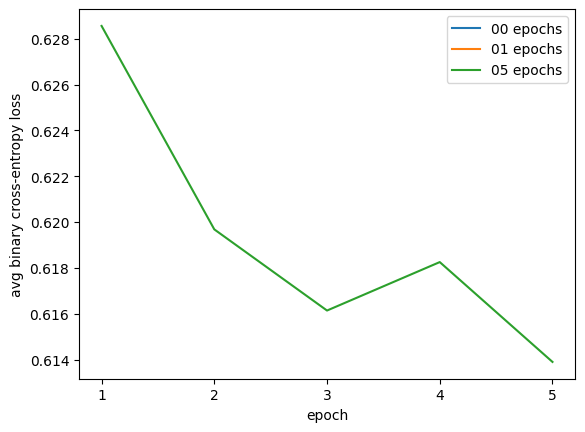

In [ ]:
# plot finetuning loss per model size

def plot_finetuning_loss(finetuning_loss, modelsize):

    fig, ax = plt.subplots()
    ax.set_xticks(range(21))
    ax.set_xlabel("epoch")
    ax.set_ylabel("avg binary cross-entropy loss")

    for name, loss_dict in finetuning_loss.items():
        if modelsize in name:
            ax.plot([i + 1 for i in loss_dict.keys()], loss_dict.values(), label = name.split("_")[1].replace("epochs", " epochs"))

    ax.legend()


plot_finetuning_loss(ftl, "3g")
plot_finetuning_loss(ftl, "4g")
plot_finetuning_loss(ftl, "50g")

In [ ]:
# get metrics on validation data during fine-tuning

def get_validation_metrics(lines_per_file, model):
    

    eval_on_valid = {}

    for row_name, lines in lines_per_file.items():

        if row_name == model:
            epoch = -1
            eval_on_valid = {}

            for i in range(len(lines)):

                l = lines[i]

                if "Load checkpoint" in l:
                    break

                if "Epoch" and "end" in l:
                    epoch = int(l.split("   ")[1].split(" ")[1])

                if "Evaluate on valid" in l:
                    metrics = {
                        "mr" : float(lines[i+1].split("   ")[1].split(" ")[1].strip()),
                        "mrr" : float(lines[i+2].split("   ")[1].split(" ")[1].strip()),
                        "hits@1" : float(lines[i+3].split("   ")[1].split(" ")[1].strip()),
                        "hits@3" : float(lines[i+4].split("   ")[1].split(" ")[1].strip()),
                        "hits@10" : float(lines[i+5].split("   ")[1].split(" ")[1].strip()),
                    }
                    eval_on_valid[epoch] = metrics

                

        df = pd.DataFrame(eval_on_valid).T

    return df.drop("mr", axis = 1), df["mr"]


df_valid, df_mr = get_validation_metrics(lpf, "4g_20epochs")
df_valid


,mrr,hits@1,hits@3,hits@10
1,0.156315,0.130233,0.162791,0.200000
3,0.161451,0.139535,0.172093,0.197674
5,0.160426,0.139535,0.169767,0.193023
7,0.149177,0.127907,0.151163,0.186047
9,0.158770,0.132558,0.174419,0.197674
11,0.166243,0.144186,0.172093,0.195349
13,0.155873,0.130233,0.165116,0.195349
15,0.161274,0.132558,0.176744,0.200000
17,0.159627,0.132558,0.169767,0.200000
19,0.157742,0.132558,0.169767,0.197674


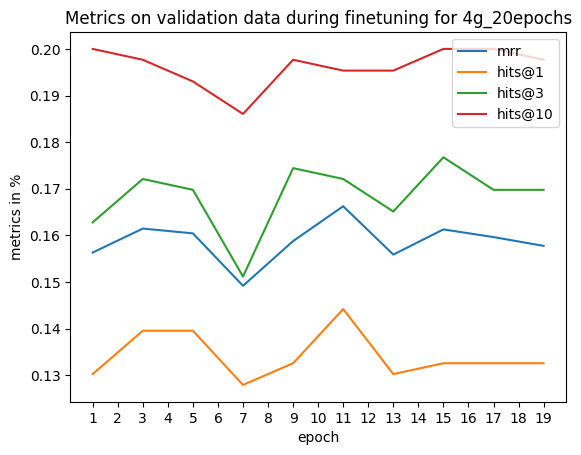

In [ ]:
# plot metrics on validation data during fine-tuning

def plot_validation_metrics(df: pd.DataFrame, modelname):

    fig, ax = plt.subplots()
    ax.set_xticks(range(21))
    ax.set_xlabel("epoch")
    ax.set_ylabel("metrics in %")
    ax.set_title(f"Metrics on validation data during finetuning for {modelname}")

    for metric in df.columns:
        print()
        ax.plot(df[metric], label = metric)

    ax.legend()


plot_validation_metrics(df_valid, "4g_20epochs")

In [6]:
# plot number of relations vs. ULTRA performance

datasets_transductive = "transductive_datasets_relations.tsv"
df_transductive = pd.read_csv(datasets_transductive, sep = "\t", header = 0, index_col = 0)
df_transductive.sort_values(by = "Rels", axis = 0, inplace = True)
df_transductive.drop("AristoV4", axis = 0, inplace = True)
df_transductive

,Entities,Rels,MRR,Hits@10
Dataset,,,,
Hetionet,45158,24,0.257,0.379
ConceptNet100k,78334,34,0.082,0.162
YAGO310,123182,37,0.451,0.615
CoDEx Small,2034,42,0.472,0.667
CoDEx Large,77951,69,0.338,0.469
WDSinger,10282,135,0.382,0.498
NELL23k,22925,200,0.239,0.408
NELL995,74536,200,0.406,0.543
FB15k237_10,11512,237,0.248,0.398


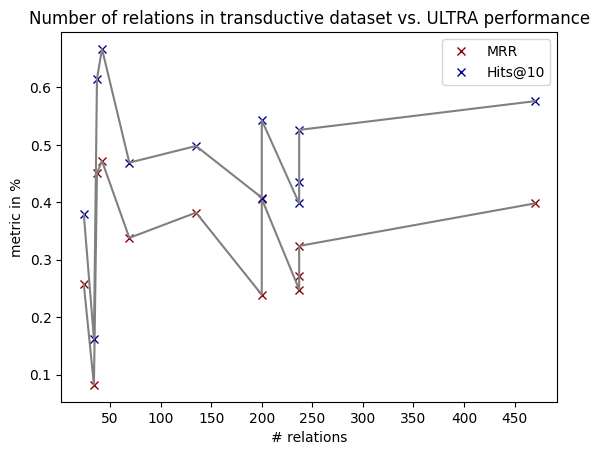

In [7]:
def plot_performance_vs_numrel(dft):

    fig, ax = plt.subplots()
    ax.set_xticks(range(0, 500, 50))
    ax.set_xlabel("# relations")
    ax.set_ylabel("metric in %")
    ax.set_title("Number of relations in transductive dataset vs. ULTRA performance")

    ax.plot(df_transductive["Rels"], df_transductive["MRR"], "x", color = "darkred", label = "MRR")
    ax.plot(df_transductive["Rels"], df_transductive["MRR"], color = "grey")

    ax.plot(df_transductive["Rels"], df_transductive["Hits@10"], "x", color = "darkblue", label = "Hits@10")
    ax.plot(df_transductive["Rels"], df_transductive["Hits@10"], color = "grey")

    ax.legend()

plot_performance_vs_numrel(df_transductive)